# Filter protein-ligand complex dataset


2022-9-8, Jue: I did a few things below to prepare the protein-ligand training data for RF2-allatom:

1. Remove training examples where the ligand is on the surface or far away from protein.

2. Remove GPCRs from main training data csv, so we can evaluate the model on GPCR docking after training and hyperparameter selection.

    Frank sent some references for the GPCR Dock competition, which mention some GPCR+ligand complexes that were used as a community-wide benchmark:
     - GPCR Dock 2008: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2728591/ (3eml)
     - GPCR Dock 2010: https://pubmed.ncbi.nlm.nih.gov/21827947/ (3pbl, 3oeu, 3oe0, 3oe6, 3oe8, 3oe9)
     - GPCR Dock 2013: https://pubmed.ncbi.nlm.nih.gov/25066135/ (4IB4, 4IAR, 4IAQ, 4jkv, 4N4W, 4QIM, 4QIN)
     - For 2021, 7vug/7vuh and 7vgx were two of the targets used. the other 3 are still unpublished (as far as I know)
     
3. Make list of test set clusters based on Ivan's previous choice of test set (astex + maybe others) as well as include the GPCR Dock targets. These will be excluded from both train and valid sets for protein/sm complex and protein datasets


Notes on training data:

 1. Ivan's original training set, only examples with ligands: `/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly.csv`
 2. Ivan's training set with test examples removed (astex + others?): `/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly_notest.csv`
 3. Rohith's protein/ligand training set (like #2 but filtering out things that openbabel can't load, and adding a path to mol2 files): `/projects/ml/RF2_allatom/list_v02_ligonly_notest_ccd_ob`
 
 
2022-10-13, Jue: I modified the protein-small molecule complex dataset:

 - Each protein-ligand pair is its own example and row in the csv file (previously each row was a protein and contained a list of ligands)
 - Each example is associated with how many other ligands are within 0.85 tanimoto similarity. this is the "ligand cluster size"
     - calculation of the tanimoto similarity is done using openbabel, with the code shown below.
 - The dataloader now computes weights for every example, factoring in the sequence length (as before), the sequence cluster size, the ligand cluster size, and the number of ligands per protein. Sequence clusters are sampled according a weight which is the sum of its members' weights. After sampleing a cluster, a cluster member is chosen by weighted sampling, using its example weight (previously this 2nd step was done uniformly).
 - The choice of ligand is now done by the datasampler, not by the loader_sm_compl function.

## Imports

In [2]:
import pandas as pd
import torch
import openbabel

import sys

sys.path.insert(0,'/home/jue/git/bff/RF2_allatom/')
from util import aa2num, atomnum2atomtype

import glob

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Calculate contacts

In [3]:
df = pd.read_csv('/projects/ml/RF2_allatom/list_v02_ligonly_notest_ccd_ob',dtype=str)

In [4]:
df.shape

(56186, 9)

In [4]:
df

,CHAINID,DEPOSITION,RESOLUTION,HASH,CLUSTER,SEQUENCE,LEN_EXIST,LIGANDS,CONTACTS
0,5nag_A,2017-02-27,1.68,082310,6750,MTATDNARQVTIIGAGLAGTLVARLLARNGWQVNLFERRPDPRIET...,448,['5nag_8R5_1_A_502__D___.mol2'],[270]
1,5nah_A,2017-02-27,1.75,082311,6750,MTATDNARQVTIIGAGLAGTLVARLLARNGWQVNLFERRPDPRIET...,447,['5nah_8RB_1_A_502__D___.mol2'],[284]
2,5nai_A,2017-02-28,1.15,067953,21385,MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRL...,230,['5nai_93W_1_A_304__E___.mol2'],[289]
3,5naj_A,2017-02-28,1.46,030830,22021,GSMSEQSICQARAAVMVYDDANKKWVPAGGSTGFSRVHIYHHTGNN...,110,['5naj_8SE_1_A_201__E___.mol2'],"[292, 83]"
4,5naj_B,2017-02-28,1.46,030830,22021,GSMSEQSICQARAAVMVYDDANKKWVPAGGSTGFSRVHIYHHTGNN...,109,"['5naj_8SE_1_B_201__I___.mol2', '5naj_8SB_1_B_...",[198]
...,...,...,...,...,...,...,...,...,...
56181,3a1s_A,2009-04-22,1.5,024914,20548,GPLHXVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,250,['3a1s_GDP_1_A_1__C___.mol2'],[277]
56182,3a1s_B,2009-04-22,1.5,024914,20548,GPLHXVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,251,['3a1s_GDP_1_B_2__H___.mol2'],[2]
56183,3a1t_A,2009-04-22,1.8,024913,20548,GPLHMVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,254,['3a1t_GDP_1_A_1__B___.mol2'],[273]
56184,3a1u_A,2009-04-22,1.8,024913,20548,GPLHMVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,252,['3a1u_GNP_1_A_1__C___.mol2'],[308]


In [4]:
df['CLUSTER'].drop_duplicates().shape

(7272,)

In [5]:
# disable openbabel warnings
from openbabel import openbabel as ob
ob.obErrorLog.SetOutputLevel(0)

In [6]:
records = []
    
for i,row in df.iterrows():

    # load protein
    pdb = torch.load('/projects/ml/TrRosetta/PDB-2021AUG02/torch/pdb/'+row['CHAINID'][1:3]+'/'+row['CHAINID']+'.pt')
    xyz_prot = pdb['xyz'][pdb['mask'].bool()]

    # loop over ligands
    sm_chains = eval(row['LIGANDS'])
    for sm_chain in sm_chains:

        filename = "/home/dimaio/ccd/by-pdb/"+row['CHAINID'][1:3]+"/"+sm_chain

        # load small molecule
        obConversion = openbabel.OBConversion()
        obConversion.SetInFormat("mol2")

        obmol = openbabel.OBMol()
        obConversion.ReadFile(obmol,filename)
        obmol.DeleteHydrogens()
        # msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])
        atoms = [(i, obmol.GetAtom(i).GetAtomicNum()) for i in range(1, obmol.NumAtoms()+1)]
        atoms = [(i, a) for (i,a) in atoms if a != 1] # filter out hydrogens that sometimes still get through
        msa = torch.tensor([aa2num[atomnum2atomtype[a]] for (i,a) in atoms])
        ins = torch.zeros_like(msa)
        xyz_sm = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i,a in atoms])

        # count contacts
        dist = torch.sqrt(torch.square(xyz_prot[:,None] - xyz_sm[None]).sum(-1))
        n_contacts = torch.sum(dist<5)

        records.append(dict(
            CHAINID = row['CHAINID'],
            LIGAND = sm_chain,
            LIGAND_N_ATOMS = float(xyz_sm.shape[0]),
            NUM_CONTACTS = int(n_contacts)
        ))

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/openbabel/__init__.py:14: UserWarning: "import openbabel" is deprecated, instead use "from openbabel import openbabel"
  warnings.warn('"import openbabel" is deprecated, instead use "from openbabel import openbabel"')


In [7]:
df2 = pd.DataFrame.from_records(records)

In [8]:
df2.shape

(77481, 4)

In [10]:
df2 = df2.merge(df[['CHAINID','CLUSTER']],on='CHAINID',how='left')

In [11]:
df2.to_csv('list_v02_ligonly_notest_ccd_ob_contacts.csv')

## Filter

In [2]:
df2 = pd.read_csv('list_v02_ligonly_notest_ccd_ob_contacts.csv',index_col=0)

In [13]:
df2[df2['CHAINID']=='1y8j_A']

,CHAINID,LIGAND,LIGAND_N_ATOMS,NUM_CONTACTS,CLUSTER
34611,1y8j_A,1y8j_STS_1_A_900__G___.mol2,19.0,250,5783


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


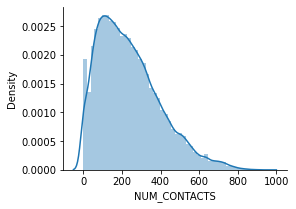

In [4]:
fig,ax = plt.subplots(figsize=(4,3))
sns.distplot(df2['NUM_CONTACTS'],ax=ax)
sns.despine()

/home/jue/.conda/envs/SE3nv/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


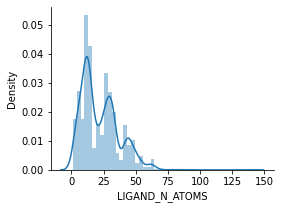

In [6]:
fig,ax = plt.subplots(figsize=(4,3))
sns.distplot(df2[df2['NUM_CONTACTS']<10]['LIGAND_N_ATOMS'],ax=ax)
sns.despine()

In [75]:
fig.savefig('contacts_hist.png',dpi=300,bbox_inches='tight')

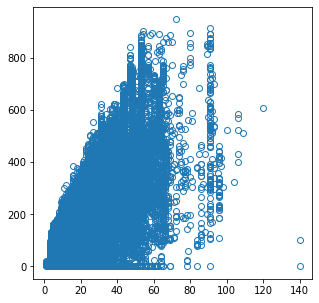

In [17]:
fig,ax = plt.subplots(figsize=(5,5))
x = 'LIGAND_N_ATOMS'
y = 'NUM_CONTACTS'
ax.plot(df2[x],df2[y],'o',markerfacecolor='none')

In [35]:
df2.shape

(77481, 4)

In [37]:
df2.drop_duplicates('CLUSTER').shape

(7272, 4)

In [38]:
df2[df2['NUM_CONTACTS']>=10].shape

(75276, 4)

In [39]:
df2[df2['NUM_CONTACTS']>=10].drop_duplicates('CLUSTER').shape

(7197, 4)

In [15]:
df2[(df2['NUM_CONTACTS']<10) & (df2['LIGAND_N_ATOMS']<10)].sort_values('NUM_CONTACTS')

,CHAINID,LIGAND,LIGAND_N_ATOMS,NUM_CONTACTS,CLUSTER
278,4ndp_A,4ndp_M10_1_A_304__Y___.mol2,6.0,0,24673
63056,5isa_A,5isa_DXE_1_A_504__P___.mol2,6.0,0,16611
33337,6xrv_E,6xrv_OCA_1_E_301__W___.mol2,9.0,0,8519
33395,6xs3_E,6xs3_OCA_1_E_301__X___.mol2,9.0,0,8519
34718,5y9m_A,5y9m_NIO_1_A_401__G___.mol2,9.0,0,10640
...,...,...,...,...,...
40680,6cj6_C,6cj6_PDO_1_C_220__GD___.mol2,5.0,9,11599
11280,3qgj_A,3qgj_TFA_1_A_210__N__D_.mol2,6.0,9,17633
10359,4q5q_A,4q5q_GSH_1_A_301__C___.mol2,1.0,9,8099
7971,2pht_A,2pht_MAN_1_A_255__E___.mol2,3.0,9,27376


I looked at some examples with 0, 1, 5, or 10 contacts, and only the 10-contact example looked good, so using this as a minimum cutoff.

I double-checked to make sure that there aren't too many examples with <10 contacts that had 1-3 ligand atoms. These would represent metal ions that maybe don't have the opportunity to make many contacts. But there are very few examples like this, so most coordinated metals, even those with only 1 atom, probably have >=10 contacts.

In [19]:
filt = df2[df2['NUM_CONTACTS']>=10]

In [20]:
records = []
for chainid in filt['CHAINID'].drop_duplicates():
    tmp = filt[filt['CHAINID']==chainid]
    records.append(dict(
        CHAINID = chainid,
        LIGANDS = list(tmp['LIGAND']),
        CONTACTS = list(tmp['NUM_CONTACTS'])
    ))

In [21]:
filt_ligands = pd.DataFrame.from_records(records)

In [22]:
filt_ligands.shape

(55258, 3)

In [23]:
df_new = df[[col for col in df.columns 
             if col != 'LIGANDS' and col != 'CONTACTS']] \
         .merge(filt_ligands, on='CHAINID', how='right')

In [24]:
df_new.shape

(55258, 9)

Make sure columns are in same order as original list

In [25]:
df_new = df_new[df.columns]

In [26]:
df_new.shape

(55258, 9)

In [27]:
df_new.to_csv('list_v02_sm_filt.csv',index=None)

Remove clusters containing GPCRs from the GPCR Dock competitions 2008, 2010, 2013, and 2021

In [28]:
import numpy as np

In [29]:
df_new = pd.read_csv('list_v02_sm_filt.csv',index_col=None,dtype=str)

In [30]:
gpcrs = ['3eml', '3pbl', '3oeu', '3oe0', '3oe6', '3oe8', '3oe9', '4ib4', '4iar', '4iaq', '4jkv', '4n4w', '4qim', '4qin',
         '7vug', '7vuh', '7vgx']

In [31]:
mask = np.any([df_new['CHAINID'].str.contains(x) for x in gpcrs], axis=0)

In [32]:
df_gpcr = df_new[mask]

In [33]:
df_gpcr.shape

(12, 9)

In [34]:
df_new = df_new[~df_new['CLUSTER'].isin(df_gpcr['CLUSTER'].values)]

In [35]:
df_new.shape

(55129, 9)

This is the filtered dataset we will use for training.

In [37]:
df_new.shape

(55129, 9)

In [38]:
df_new.to_csv('list_v02_sm_filt_notest.csv',index=None)

## Test set
Put astex and gpcr clusters in a list, to be used to exclude examples from training and validation in other datasets (PDB monomer, etc)

Ivan's original training set, only examples with ligands

In [71]:
orig = pd.read_csv('/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly.csv')

In [72]:
orig.shape

(78711, 9)

Ivan's training set with test examples removed (astex + others?)

In [73]:
notest = pd.read_csv('/projects/ml/TrRosetta/PDB-2021AUG02/list_v02_ligonly_notest.csv')

In [74]:
notest.shape

(66863, 9)

Clusters that are in test set

In [75]:
test_clus = np.setdiff1d(orig['CLUSTER'].drop_duplicates(), notest['CLUSTER'].drop_duplicates())

In [76]:
test_clus.shape

(48,)

In [92]:
test_clus

array([  321,   430,   725,   950,  1694,  2767,  2798,  3102,  3233,
        4285,  4736,  4935,  5300,  6840,  7324,  7436,  7757,  8667,
        9249,  9276, 11050, 12969, 14163, 14175, 15132, 15643, 15961,
       16646, 16713, 16823, 18013, 19157, 21149, 21673, 22651, 23531,
       23791, 24229, 24539, 25542, 25637, 25830, 25841, 25867, 26519,
       26885, 27044, 27679])

Hashes (PDB entries) that are in test set

In [77]:
test_hash = np.setdiff1d(orig['HASH'].drop_duplicates(), notest['HASH'].drop_duplicates())

In [78]:
test_hash.shape

(2905,)

PDB chains that are in test set

In [79]:
orig_test = orig[~orig['CHAINID'].isin(notest['CHAINID'].values)]

In [80]:
orig_test.shape

(11848, 9)

Current `lig_test` file contains 16787 entries that are integers. Not sure how that corresponds to the info in these tables.

We will make a new list `sm_heldout_test_clusters` containing the cluster IDs of Ivan's test examples, plus the GPCRs from above.

In [93]:
df_gpcr['CLUSTER'].drop_duplicates()

2899     24395
5127      6005
8013     20696
46754    21380
Name: CLUSTER, dtype: int64

In [90]:
all_test_clus = np.unique(np.concatenate([test_clus,df_gpcr['CLUSTER']]))

In [91]:
all_test_clus

array([  321,   430,   725,   950,  1694,  2767,  2798,  3102,  3233,
        4285,  4736,  4935,  5300,  6005,  6840,  7324,  7436,  7757,
        8667,  9249,  9276, 11050, 12969, 14163, 14175, 15132, 15643,
       15961, 16646, 16713, 16823, 18013, 19157, 20696, 21149, 21380,
       21673, 22651, 23531, 23791, 24229, 24395, 24539, 25542, 25637,
       25830, 25841, 25867, 26519, 26885, 27044, 27679])

In [94]:
with open('sm_test_heldout_test_clusters.txt','w') as outf:
    for i in all_test_clus:
        print(i, file=outf)

## Bad examples
This is just to document some bad examples that I saw when preparing the above.

### Hydrogen that can't be removed
TODO:
 - How many of these are there?
 - Do these come from non-H atoms in the input file? In this case we should set them to unknown (ATM) rather than removing

In [59]:
filename = '/home/dimaio/ccd/by-pdb/wv/6wv5_UAV_1_A_401__B___.mol2'

# load small molecule
obConversion = openbabel.OBConversion()
obConversion.SetInFormat("mol2")

obmol = openbabel.OBMol()
obConversion.ReadFile(obmol,filename)
obmol.DeleteHydrogens()

# old code: should error
msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])

KeyError: 1

In [58]:
# new code that filters out hydrogen
atoms = [(i, obmol.GetAtom(i).GetAtomicNum()) for i in range(1, obmol.NumAtoms()+1)]
atoms = [(i, a) for (i,a) in atoms if a != 1] # filter out hydrogens that sometimes still get through
msa = torch.tensor([aa2num[atomnum2atomtype[a]] for (i,a) in atoms])

In [51]:
ins = torch.zeros_like(msa)
xyz_sm = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i,a in atoms])

# count contacts
dist = torch.sqrt(torch.square(xyz_prot[:,None] - xyz_sm[None]).sum(-1))
n_contacts = torch.sum(dist<5)

records.append(dict(
    CHAINID = row['CHAINID'],
    LIGAND = sm_chain,
    NUM_CONTACTS = n_contacts
))

## Cluster by small molecules
2022-10-11

In [5]:
import numpy as np
import pandas as pd
import os

from openbabel import openbabel, pybel
openbabel.obErrorLog.SetOutputLevel(0) # disable openbabel warnings

In [6]:
istart = 0
num = 100

In [9]:
df = pd.read_csv('list_v02_sm_filt_notest.csv',index_col=None,dtype=str)

In [10]:
df

,CHAINID,DEPOSITION,RESOLUTION,HASH,CLUSTER,SEQUENCE,LEN_EXIST,LIGANDS,CONTACTS
0,5nag_A,2017-02-27,1.68,082310,6750,MTATDNARQVTIIGAGLAGTLVARLLARNGWQVNLFERRPDPRIET...,448,['5nag_8R5_1_A_502__D___.mol2'],[270]
1,5nah_A,2017-02-27,1.75,082311,6750,MTATDNARQVTIIGAGLAGTLVARLLARNGWQVNLFERRPDPRIET...,447,['5nah_8RB_1_A_502__D___.mol2'],[284]
2,5nai_A,2017-02-28,1.15,067953,21385,MLKVISSLLVYMTASVMAVASPLAHSGEPSGEYPTVNEIPVGEVRL...,230,['5nai_93W_1_A_304__E___.mol2'],[289]
3,5naj_A,2017-02-28,1.46,030830,22021,GSMSEQSICQARAAVMVYDDANKKWVPAGGSTGFSRVHIYHHTGNN...,110,['5naj_8SE_1_A_201__E___.mol2'],[292]
4,5naj_B,2017-02-28,1.46,030830,22021,GSMSEQSICQARAAVMVYDDANKKWVPAGGSTGFSRVHIYHHTGNN...,109,"['5naj_8SE_1_B_201__I___.mol2', '5naj_8SB_1_B_...","[279, 198]"
...,...,...,...,...,...,...,...,...,...
55124,3a1s_A,2009-04-22,1.5,024914,20548,GPLHXVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,250,['3a1s_GDP_1_A_1__C___.mol2'],[277]
55125,3a1s_B,2009-04-22,1.5,024914,20548,GPLHXVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,251,['3a1s_GDP_1_B_2__H___.mol2'],[264]
55126,3a1t_A,2009-04-22,1.8,024913,20548,GPLHMVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,254,['3a1t_GDP_1_A_1__B___.mol2'],[273]
55127,3a1u_A,2009-04-22,1.8,024913,20548,GPLHMVKVALAGCPNVGKTSLFNALTGTKQYVANWPGVTVEKKEGV...,252,['3a1u_GNP_1_A_1__C___.mol2'],[308]


In [35]:
all_ligand_files = []
for i,row in df.iterrows():
    all_ligand_files.extend([
        f'/projects/ml/RF2_allatom/by-pdb/{row["CHAINID"][1:3]}/'+x for x in eval(row['LIGANDS'])
    ])

In [36]:
len(all_ligand_files)

74996

In [37]:
mols = [next(pybel.readfile('mol2',fn)) for fn in all_ligand_files]

fps = [mol.calcfp() for mol in mols]

In [39]:
len(fps)

74996

In [46]:
%%time
clus = []
sim_s = []
for fp in fps[:200]:
    sim = np.array([fp|fp2 for fp2 in fps])
    sim_s.append(sim)
    clus.append([(sim>0.9).sum(), (sim>0.85).sum(), (sim>0.8).sum(), (sim>0.75).sum(), (sim>0.7).sum()])

CPU times: user 12.3 s, sys: 167 ms, total: 12.5 s
Wall time: 12.5 s


In [42]:
(5000/100*6)/60

5.0

In [43]:
sim_s = np.vstack(sim_s)

In [44]:
names = [os.path.basename(fn) for fn in all_ligand_files]

In [18]:
np.savez(f'ob_tanimoto_{istart}.npz',names=names,sim=sim_s,clus=clus)

Put the above code in a script and ran it in parallel on digs:

    for i in `seq 0 5000 74900`; do sbatch -p cpu --mem 16G -t 20:00 --wrap "source activate dlchem; python tanimoto_cluster.py -istart $i -num 5000"; done

In [16]:
names = []
clus = []
iden = []
for i in range(0,74900,5000):
    print(i)
    dat = np.load(f'ob_tanimoto_{i}.npz')
    # names.extend(dat['names'])
    clus.extend(dat['clus'])
    # iden.append(dat['sim']==1)

0
5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
55000
60000
65000
70000


In [17]:
names = np.array(dat['names'])

In [92]:
names.shape

(74996,)

In [22]:
clus = np.vstack(clus)

In [23]:
clus.shape

(74996, 5)

In [30]:
clus[49370]

array([0, 0, 0, 0, 0])

In [ ]:
iden = np.vstack(iden)

In [4]:
iden.shape

(74996, 74996)

How big are the clusters?

In [13]:
import matplotlib.pyplot as plt

(array([46849.,  5877.,  7218.,  2356.,  4547.,   280.,  3734.,   167.,
         2104.,  1864.]),
 array([   0.,  560., 1120., 1680., 2240., 2800., 3360., 3920., 4480.,
        5040., 5600.]),
 <BarContainer object of 10 artists>)

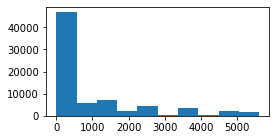

In [65]:
fig,ax = plt.subplots(figsize=(4,2))
ax.hist(clus[:,1])

What are some of the molecules in large clusters?

In [97]:
large_clus = names[clus[:,1]>4000]

In [98]:
large_clus

array(['6nab_AMP_1_A_601__C___.mol2', '6nas_ATP_1_A_401__E___.mol2',
       '1nb0_ADP_1_A_301__C___.mol2', ..., '1b76_ATP_1_A_1552__C___.mol2',
       '1b7t_ADP_1_A_999__G___.mol2', '3a1d_ADP_1_A_997__C___.mol2'],
      dtype='<U30')

In [94]:
large_clus = names[(clus[:,1]<4000) & (clus[:,1]>3000)]

In [95]:
len(large_clus)

3802

In [96]:
large_clus

array(['1nbb_HEM_1_A_130__C___.mol2', '6nbc_HEM_1_A_201__E___.mol2',
       '6nbc_HEM_2_A_201__E___.mol2', ..., '3a17_HEM_1_A_354__I___.mol2',
       '3a17_HEM_1_B_354__K___.mol2', '3a1l_HEM_1_A_500__B___.mol2'],
      dtype='<U30')

In [86]:
large_clus = names[(clus[:,1]<3000) & (clus[:,1]>2000)]

In [87]:
len(large_clus)

4891

In [88]:
large_clus

array(['6na4_NAP_1_A_501__E___.mol2', '3nbv_ANP_1_A_299__C___.mol2',
       '3nbv_ANP_1_B_299__E___.mol2', ..., '3a1s_GDP_1_A_1__C___.mol2',
       '3a1s_GDP_1_B_2__H___.mol2', '3a1t_GDP_1_A_1__B___.mol2'],
      dtype='<U30')

Makes sense

In [99]:
df.shape

(55129, 9)

In [11]:
rows = []
for i,row in df.iterrows():
    for lig, con in zip(eval(row['LIGANDS']),eval(row['CONTACTS'])):
        newrow = row[row.keys()[:-2]].copy()
        newrow['LIGAND'] = lig
        newrow['CONTACTS'] = con
        rows.append(newrow)

In [12]:
df2 = pd.DataFrame.from_records(rows)

In [13]:
df2.shape

(74996, 9)

In [14]:
df2['CLUSTER_SIZE'] = 1

In [15]:
tmp = df2.groupby('CLUSTER').sum().reset_index()[['CLUSTER','CLUSTER_SIZE']]

In [18]:
df2 = df2[['CHAINID','DEPOSITION','RESOLUTION','HASH','CLUSTER','SEQUENCE','LEN_EXIST','LIGAND','CONTACTS']]\
      .merge(tmp, on='CLUSTER', how='left')

In [24]:
df2['LIGAND_CLUSTER_SIZE'] = clus[:,1] # number of neighbors with tanimoto > 0.85

In [25]:
df2.shape

(74996, 11)

In [26]:
tmp = df2.copy()
tmp['NUM_LIGANDS'] = 1
tmp = tmp.groupby('CHAINID').sum().reset_index()[['CHAINID','NUM_LIGANDS']]
df2 = df2.merge(tmp,on='CHAINID',how='left')

In [32]:
df2.shape

(74996, 12)

In [28]:
df2.to_csv('list_v02_sm_filt_notest_reclustered.csv',index=None)

### Try tanimoto on one example

These are the 1st 2 examples in the datafra. They looks quite similar by eye, but have a suprisingly low tanimoto similarity. After looking at a few more examples I think generally the similarity clustering will do what we intend (downweight sampling of ATP, heme, etc), despite potentially oversampling small ligands that don't differ very much.

In [45]:
mol1 = next(pybel.readfile('mol2','/projects/ml/RF2_allatom/by-pdb/na/5nag_8R5_1_A_502__D___.mol2'))
mol2 = next(pybel.readfile('mol2','/projects/ml/RF2_allatom/by-pdb/na/5nah_8RB_1_A_502__D___.mol2'))

In [46]:
fp1 = mol1.calcfp()
fp2 = mol2.calcfp()

In [29]:
fp1 | fp2

0.7391304347826086

In [49]:
len(fp1.bits)

157

In [50]:
len(fp2.bits)

163

In [52]:
len(np.intersect1d(fp1.bits,fp2.bits))/len(np.union1d(fp1.bits,fp2.bits))

0.7391304347826086

Try doing this with Ivan's RDKit code

In [30]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit import RDLogger
from rdkit.Chem.Fingerprints import FingerprintMols

RDLogger.DisableLog('rdApp.*')

In [33]:
mol1 = Chem.MolFromMol2File('/projects/ml/RF2_allatom/by-pdb/na/5nag_8R5_1_A_502__D___.mol2')

In [34]:
mol2 = Chem.MolFromMol2File('/projects/ml/RF2_allatom/by-pdb/na/5nah_8RB_1_A_502__D___.mol2')

In [35]:
mol1 = Chem.AddHs(mol1)

In [36]:
mol2 = Chem.AddHs(mol2)

In [38]:
fpArgs = {'minPath' : 1,
          'maxPath' : 7,
          'fpSize' : 2048,
          'bitsPerHash' : 2,
          'useHs' : True,
          'tgtDensity' : 0.0,
          'minSize' : 128}

In [39]:
fp1 = FingerprintMols.FingerprintMol(mol1,**fpArgs)

In [40]:
fp2 = FingerprintMols.FingerprintMol(mol2,**fpArgs)

In [42]:
sim = DataStructs.BulkTanimotoSimilarity(fp1,[fp2])

In [43]:
sim

[0.8323754789272031]

This is higher, but still below the 0.85 cutoff. Let's not worry about this for now.

Here is the similarity between ADP and AMP, which are both in the largest cluster

In [80]:
mol1 = next(pybel.readfile('mol2','/projects/ml/RF2_allatom/by-pdb/na/6nab_AMP_1_A_601__C___.mol2'))
mol2 = next(pybel.readfile('mol2','/projects/ml/RF2_allatom/by-pdb/nb/1nb0_ADP_1_A_301__C___.mol2'))

In [81]:
fp1 = mol1.calcfp()
fp2 = mol2.calcfp()

In [82]:
fp1 | fp2

0.9194630872483222

## Merge examples with identical ligands
2022-10-17

Rohith found cases where a ligand could bind in either of 2 different locations on a protein. We should add alternate binding sites to the symmetry dimension so the loss doesn't penalize them.

I'm going to modify the dataset table so that instead of a row for each protein-ligand pair, it's a row for each UNIQUE protein ligand pair, with a list of ligand files for all the alternate binding locations.

In [34]:
df = pd.read_csv('list_v02_sm_filt_notest_reclustered.csv')

In [35]:
df.shape

(74996, 12)

In [36]:
df.drop_duplicates(['CHAINID','LIGAND']).shape

(74996, 12)

In [37]:
df['LIGAND_NAME'] = df['LIGAND'].apply(lambda x: x.split('_')[1])

Initially tried to simply group entries by LIGAND_NAME, but ~1500 of these names actually end up being different molecules when you open the mol2 files (see analysis block below). We currently just ignore any ligands with same name but different atoms, but eventually should deal with these (some of these are mol2 files representing part of a ligand that need to be covalently linked to the ligand in other mol2 files)

In [138]:
df2 = df[['CHAINID','LIGAND','LIGAND_NAME','CONTACTS']].groupby(['CHAINID','LIGAND_NAME'],as_index=False,sort=False).agg(lambda x: list(x))

In [139]:
df2.shape

(63945, 4)

In [140]:
df2[df2['LIGAND'].apply(lambda x: len(x))>1]

,CHAINID,LIGAND_NAME,LIGAND,CONTACTS
8,6na3_A,VES,"[6na3_VES_1_A_501__E___.mol2, 6na3_VES_1_A_502...","[81, 16]"
33,3nb0_A,G6P,"[3nb0_G6P_1_A_902__F___.mol2, 3nb0_G6P_1_A_901...","[108, 179]"
34,3nb0_B,G6P,"[3nb0_G6P_1_B_902__J___.mol2, 3nb0_G6P_1_B_901...","[151, 182]"
37,3nbf_A,8OD,"[3nbf_8OD_1_A_600__F___.mol2, 3nbf_8OD_1_A_500...","[233, 173]"
38,3nbf_C,8OP,"[3nbf_8OP_1_C_500__J___.mol2, 3nbf_8OP_1_C_501...","[192, 128]"
...,...,...,...,...
63847,4nah_A,2VJ,"[4nah_2VJ_1_A_203__I___.mol2, 4nah_2VJ_1_A_202...","[263, 90]"
63850,4naj_A,AZI,"[4naj_AZI_1_A_412__M___.mol2, 4naj_AZI_1_A_413...","[19, 58, 40]"
63874,1b7e_A,TPT,"[1b7e_TPT_1_A_481__C___.mol2, 1b7e_TPT_1_A_480...","[144, 155]"
63877,1b7z_A,OXL,"[1b7z_OXL_1_A_692__D___.mol2, 1b7z_OXL_1_A_693...","[171, 172]"


In [141]:
df = df.drop(['LIGAND','CONTACTS'],axis=1)

In [142]:
df = df.merge(df2, on=['CHAINID','LIGAND_NAME'],how='inner')

In [143]:
df.shape

(74996, 13)

In [144]:
df = df.drop_duplicates(['CHAINID','LIGAND_NAME'])

In [148]:
df = df.rename(columns={'LIGAND':'LIGANDS'})

In [149]:
df.shape

(63945, 13)

In [151]:
df[df['LIGANDS'].apply(lambda x: len(x)>1)]

,CHAINID,DEPOSITION,RESOLUTION,HASH,CLUSTER,SEQUENCE,LEN_EXIST,CLUSTER_SIZE,LIGAND_CLUSTER_SIZE,NUM_LIGANDS,LIGAND_NAME,LIGANDS,CONTACTS
8,6na3_A,2018-12-05,1.800,94136,6879,RHMQEILDAILSGDAASADYAALALPESYRAVTLHKGEERMFDGLA...,445,19,4,2,VES,"[6na3_VES_1_A_501__E___.mol2, 6na3_VES_1_A_502...","[81, 16]"
34,3nb0_A,2010-06-02,2.406,59379,7884,MGSSHHHHHHSSGLVPRGSHMSRDLQNHLLFETATEVANRVGGIYS...,638,41,299,2,G6P,"[3nb0_G6P_1_A_902__F___.mol2, 3nb0_G6P_1_A_901...","[108, 179]"
36,3nb0_B,2010-06-02,2.406,59379,7884,MGSSHHHHHHSSGLVPRGSHMSRDLQNHLLFETATEVANRVGGIYS...,645,41,299,2,G6P,"[3nb0_G6P_1_B_902__J___.mol2, 3nb0_G6P_1_B_901...","[151, 182]"
40,3nbf_A,2010-06-03,1.900,50567,15784,MEFKDFPLKPEILEALHGRGLTTPTPIEAAALPLALEGKDLIGQAR...,207,14,4244,2,8OD,"[3nbf_8OD_1_A_600__F___.mol2, 3nbf_8OD_1_A_500...","[233, 173]"
42,3nbf_C,2010-06-03,1.900,50567,15784,MEFKDFPLKPEILEALHGRGLTTPTPIEAAALPLALEGKDLIGQAR...,207,14,791,3,8OP,"[3nbf_8OP_1_C_500__J___.mol2, 3nbf_8OP_1_C_501...","[192, 128]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74892,4nah_A,2013-10-22,2.380,50785,4847,MEHTIAVIPGSFDPITYGHLDIIERSTDRFDEIHVCVLKNSKKEGT...,159,101,2,3,2VJ,"[4nah_2VJ_1_A_203__I___.mol2, 4nah_2VJ_1_A_202...","[263, 90]"
74896,4naj_A,2013-10-22,2.600,49527,23805,MDRRGFNRRVLLGGAAAATSLSIAPEVAGAAPAAKGITARTAPAGG...,279,11,265,3,AZI,"[4naj_AZI_1_A_412__M___.mol2, 4naj_AZI_1_A_413...","[19, 58, 40]"
74922,1b7e_A,1999-01-22,2.900,73210,19851,MQEGAYRFIRNPNVSAEAIRKAGAMQTVKLAQEFPELLAIEDTTSL...,372,2,6,2,TPT,"[1b7e_TPT_1_A_481__C___.mol2, 1b7e_TPT_1_A_480...","[144, 155]"
74926,1b7z_A,1999-01-26,2.700,4635,15440,APRKSVRWCTISPAEAAKCAKFQRNMKKVRGPSVSCIRKTSSFECI...,689,69,145,2,OXL,"[1b7z_OXL_1_A_692__D___.mol2, 1b7z_OXL_1_A_693...","[171, 172]"


In [152]:
df.to_csv('list_v02_smcompl_20221017.csv')

### Ligands with different shapes
2022-10-18

Tried to train and saw there were some ligands that should be the same but have different shapes. Make a list of these and clean them.

In [2]:
import pandas as pd
import ast
import sys, os
sys.path.insert(0,'/home/jue/git/rf2a-dev/')
from data_loader import *
from argparse import Namespace

In [3]:
args = Namespace()

In [4]:
params = set_data_loader_params(args)

In [5]:
# parse protein-small molecule complexes
df = pd.read_csv('list_v02_smcompl_20221017.csv')

In [6]:
df.shape

(63945, 14)

In [7]:
df['HASH'] = df['HASH'].apply(lambda x: f'{x:06d}') # restore leading zeros, make into string
df['LIGANDS'] = df.LIGANDS.apply(lambda x: ast.literal_eval(x)) # interpret as list of strings
df = df[
    (df.RESOLUTION<=params['RESCUT']) &
    (df.DEPOSITION.apply(lambda x: parser.parse(x))<=parser.parse(params['DATCUT'])) &
    ~df.LIGANDS.apply(lambda x: '1fcv_GCU_1_A_405__B___.mol2' in x) & # malformatted, tanimoto neighbors=0, weight=Inf
    (df.CHAINID != '6uiw_A') # causes GPU OOM for some reason
]

In [8]:
# weight each example by various factors
seq_len_factor = (1/512.)*np.clip(df.LEN_EXIST, 256, 512) # sample longer sequences more often
multi_lig_factor = df['LIGANDS'].apply(lambda x: len(x))/df.NUM_LIGANDS.astype(float) # num of this ligand versus total ligands for this protein chain
ligand_cluster_factor = 1./df.LIGAND_CLUSTER_SIZE # how many other sm mol have tanimoto > 0.85 to this?
seq_cluster_factor = 1./df.CLUSTER_SIZE # protein seq similarity cluster size
df['WEIGHT'] = seq_len_factor * multi_lig_factor * ligand_cluster_factor * seq_cluster_factor

In [9]:
val_pdb_ids = set([int(l) for l in open(params['VAL_PDB']).readlines()])

In [10]:
# compile protein-sm. mol examples
train_sm_compl = {}
valid_sm_compl = {}
for i,row in df.iterrows():
    entry = ((row.CHAINID, row.HASH, row.LIGANDS), row.LEN_EXIST, row.WEIGHT)
    if row.CLUSTER in val_pdb_ids:
        if row.CLUSTER in valid_sm_compl.keys():
            valid_sm_compl[row.CLUSTER].append(entry)
        else:
            valid_sm_compl[row.CLUSTER] = [entry]
    else:
        if row.CLUSTER in train_sm_compl.keys():
            train_sm_compl[row.CLUSTER].append(entry)
        else:
            train_sm_compl[row.CLUSTER] = [entry]

In [13]:
# disable openbabel warnings
from openbabel import openbabel as ob
ob.obErrorLog.SetOutputLevel(0)

In [14]:
with open('nonidentical_ligands.txt','w') as f:
    for k,v in train_sm_compl.items():
        for token in v:
            if len(token[0][2])>1:
                item = token[0]
                pdb_chain, pdb_hash, ligands = item
                mol, msa_sm, ins_sm, xyz_sm, mask_sm = \
                    parse_mol(params["MOL_DIR"]+"/"+pdb_chain[1:3]+"/"+ligands[0])
                for alt_lig in ligands[1:]:    
                    mol2, msa_sm2, ins_sm2, xyz_sm2, mask_sm2 = parse_mol(params["MOL_DIR"]+"/"+pdb_chain[1:3]+"/"+alt_lig)
                    if (msa_sm.shape==msa_sm2.shape) and all(msa_sm2==msa_sm):
                        pass
                    else:
                        print(item,file=f)

*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exceeded...
*** Open Babel Error  in operator()
  memory limit exce

ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/oa/4oay_C2E_1_A_201__M___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/sy/3sys_C8E_1_A_405__I___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/sz/3szv_C8E_1_A_386__C___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/y2/2y2x_C8E_1_A_1397__I___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/fo/4foz_C8E_1_A_502__C___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/fo/4foz_C8E_1_A_506__G___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/jx/4jxc_1N7_1_A_404__E___.mol2 yielded invalid tensor
ERROR: automorphs for /projects/ml/RF2_allatom/by-pdb/gf/4gf4_C8E_1_A_504__E___.mol2 yielded invalid tensor


In [38]:
mol, msa_sm, ins_sm, xyz_sm, mask_sm = parse_mol('/projects/ml/RF2_allatom/by-pdb/c9/3c9e_BDP_1_A_301__B___.mol2')

In [39]:
xyz_sm.shape

torch.Size([1, 13, 3])

In [52]:
mol2, msa_sm2, ins_sm2, xyz_sm2, mask_sm2 = parse_mol('/projects/ml/RF2_allatom/by-pdb/c9/3c9e_BDP_1_A_303__B___.mol2')

In [53]:
xyz_sm2.shape

torch.Size([1, 12, 3])

In [54]:
mol2, msa_sm3, ins_sm2, xyz_sm3, mask_sm2 = parse_mol('/projects/ml/RF2_allatom/by-pdb/c9/3c9e_BDP_1_A_305__B___.mol2')

In [55]:
xyz_sm3.shape

torch.Size([1, 12, 3])

xyz_sm2.shape

### Testing ligand grouping code
This code will compare ligand atom lists and assign a unique id to each set of identical ligands

Examples come from the list "nonidentical_ligands.txt" as generated above

In [100]:
tmp = df[df['CHAINID']=='3c9e_A']

In [101]:
chainid = tmp['CHAINID'].values[0]

In [102]:
lig_atoms = []
for lig in tmp['LIGAND']:
    mol, msa_sm, ins_sm, xyz_sm, mask_sm = parse_mol('/projects/ml/RF2_allatom/by-pdb/'+chainid[1:3]+'/'+lig)
    lig_atoms.append(msa_sm)

In [103]:
lig_atoms

[tensor([39, 39, 39, 39, 39, 39, 57, 57, 57, 57, 57, 57, 57]),
 tensor([39, 39, 39, 39, 39, 39, 57, 57, 57, 57, 57, 57]),
 tensor([39, 39, 39, 39, 39, 39, 57, 57, 57, 57, 57, 57]),
 tensor([39, 57, 57, 39, 39, 57, 39, 57, 55, 39, 39, 39, 39, 39, 39, 57, 55, 39,
         39, 39, 39, 55, 39, 55, 55])]

In [104]:
lig_id_s = [None]*len(lig_atoms)
curr_id = 0
for i in range(len(lig_atoms)):
    matched = False
    for j in range(i):
        if lig_atoms[i].shape==lig_atoms[j].shape and all(lig_atoms[i]==lig_atoms[j]):
            lig_id_s[i] = lig_id_s[j]
            matched = True
            break
    if not matched:
        lig_id_s[i] = curr_id
        curr_id += 1

In [105]:
lig_id_s

[0, 1, 1, 2]

## Train/Valid tanimoto overlap
2022-10-17

Want to know which validation set examples contain a ligand that overlaps with training set examples.

Use this to curate a "stringent" validation set that only contains ligand that do not overlap with training set.

In [106]:
import numpy as np

In [107]:
df = pd.read_csv('list_v02_sm_filt_notest_reclustered.csv')

In [114]:
df.shape

(74996, 12)

### Assign ligand clusters

In [170]:
clus = np.full((len(df),),-1)
assigned = np.full((len(df),),False)

In [171]:
for istart in range(0,74900,5000):
    print(istart)
    dat = np.load(f'ob_tanimoto_{istart}.npz')
    sim = dat['sim']

    hits = sim>0.85

    iclus = 0
    for j in np.arange(min(5000,len(df)-istart)):
        if clus[istart+j] != -1:
            continue
        else:
            clus[hits[j] & (~assigned)] = iclus
            assigned = assigned | hits[j]
            iclus += 1

0
5000
10000
15000
20000
25000
30000
35000
40000
45000
50000
55000
60000
65000
70000


IndexError: index 74996 is out of bounds for axis 0 with size 74996

In [172]:
clus.max()

1478

This weird example doesn't have similarity to itself and gets excluded during training

In [174]:
(clus==-1).sum()

1

In [ ]:
np.where(clus==-1)

(array([49370]),)

In [176]:
df.iloc[49370]

CHAINID                                                           1fcv_A
DEPOSITION                                                    2000-07-19
RESOLUTION                                                          2.65
HASH                                                              105343
CLUSTER                                                              744
SEQUENCE               TPDNNKTVREFNVYWNVPTFMCHKYGLRFEEVSEKYGILQNWMDKF...
LEN_EXIST                                                            323
LIGAND                                       1fcv_GCU_1_A_405__B___.mol2
CONTACTS                                                              10
CLUSTER_SIZE                                                           3
LIGAND_CLUSTER_SIZE                                                    0
NUM_LIGANDS                                                            3
Name: 49370, dtype: object

In [178]:
df['LIGAND_CLUSTER'] = clus

### Filter validation set by ligand cluster overlap

In [195]:
val_pdb_ids = set([int(l) for l in open('/projects/ml/RF2_allatom/valid_remapped').readlines()])

In [196]:
len(val_pdb_ids)

1211

In [206]:
train_pdb_ids = np.setdiff1d(df['CLUSTER'].drop_duplicates(),list(val_pdb_ids))

In [207]:
len(train_pdb_ids)

6786

In [208]:
df_train = df[df['CLUSTER'].isin(train_pdb_ids)]

In [209]:
df_train.shape

(70643, 13)

In [273]:
df_valid = df[df['CLUSTER'].isin(val_pdb_ids)]

In [274]:
df_valid.shape

(4353, 13)

Validation set but keeping only one example per ligand cluster

In [275]:
df_val_dedup = df_valid.sample(len(df_valid)).drop_duplicates('LIGAND_CLUSTER').drop_duplicates('CHAINID')

In [276]:
df_val_dedup.shape

(705, 13)

In [277]:
df_val_dedup.drop_duplicates('CLUSTER').shape

(217, 13)

In [278]:
df_val_dedup['LIGANDS'] = df_val_dedup['LIGAND'].apply(lambda x: [x])

In [279]:
df_val_dedup = df_val_dedup.drop(['LIGAND'],axis=1)

In [280]:
df_val_dedup = df_val_dedup[
    ~df_val_dedup.LIGANDS.apply(lambda x: '1fcv_GCU_1_A_405__B___.mol2' in x) & # malformatted, tanimoto neighbors=0, weight=Inf
    (df_val_dedup.CHAINID != '6uiw_A') # causes GPU OOM for some reason
]

In [281]:
df_val_dedup.shape

(705, 13)

In [282]:
df_val_dedup.to_csv('list_v02_smcompl_ligclusvalid_20221018.csv')

Validation set but removing all ligand cluster overlaps with training set

In [283]:
df_val_filt = df_valid[~df_valid['LIGAND_CLUSTER'].isin(df_train['LIGAND_CLUSTER'].values)]

In [284]:
df_val_filt.shape

(36, 13)

In [286]:
df_val_filt.drop_duplicates('LIGAND_CLUSTER').shape

(11, 13)

In [287]:
df_val_filt.drop_duplicates('CLUSTER').shape

(8, 13)

In [289]:
df_val_filt['LIGANDS'] = df_val_filt['LIGAND'].apply(lambda x: [x])

/scratch/jue/6363544/ipykernel_3784958/3827491519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_filt['LIGANDS'] = df_val_filt['LIGAND'].apply(lambda x: [x])


In [290]:
df_val_filt = df_val_filt.drop(['LIGAND'],axis=1)

In [294]:
df_val_filt.to_csv('list_v02_smcompl_validstrict_20221018.csv')

## Peptide validation set
2022-10-19

Compile set of protein-peptide complexes to see if atomized protein training task improves performance on protein-peptide docking with an atomized peptide.

List of peptide examples is from Supplementary Data S1 of Johansson-Akhe et al (2022) Frontiers in Bioinformatics.

First try to get peptide benchmark examples that are in current validation set.

In [98]:
df = pd.read_csv('list_v02_sm_filt_notest_reclustered.csv')

In [99]:
val_pdb_ids = set([int(l) for l in open('/projects/ml/RF2_allatom/valid_remapped').readlines()])

In [100]:
df_val = df[df['CLUSTER'].isin(val_pdb_ids)]

In [101]:
df_val.shape

(4353, 12)

In [102]:
df_train = df[~df['CLUSTER'].isin(val_pdb_ids)]

In [103]:
df_train.shape

(70643, 12)

In [104]:
dfpep = pd.read_csv('akhe2022_dataS1_pos_examples.csv')

In [105]:
pep = dfpep.apply(lambda row: row['pdb_id']+'_'+row['prot_chain'],axis=1).values

In [106]:
df_val[df_val['CHAINID'].isin(pep)].shape

(0, 12)

In [107]:
df_train[df_train['CHAINID'].isin(pep)].shape

(31, 12)

See if peptide benchmark examples are in original training set (before removing things for test set, etc)

In [112]:
df = pd.read_csv('/projects/ml/TrRosetta/PDB-2021AUG02/list_v02.csv')

In [113]:
df = df[df['CHAINID'].isin(pep)]

In [114]:
df.shape

(95, 7)

In [119]:
dfpep['CHAINID'] = dfpep.apply(lambda row: row['pdb_id']+'_'+row['prot_chain'],axis=1)

In [121]:
dfpep['PEP_CHAINID'] = dfpep.apply(lambda row: row['pdb_id']+'_'+row['pep_chain'],axis=1)

In [123]:
df = df.merge(dfpep[['CHAINID','PEP_CHAINID']], on='CHAINID', how='left')

In [124]:
df.shape

(95, 8)

In [126]:
df = df[~df['CLUSTER'].isin(df_train['CLUSTER'].values)]

In [127]:
df.shape

(44, 8)

In [128]:
df['CLUSTER'].drop_duplicates().shape

(43,)

In [131]:
import os

Check if we have torch parsed versions of the protein and peptide chains

In [135]:
records = []
for i,row in df.iterrows():
    if not os.path.exists('/projects/ml/TrRosetta/PDB-2021AUG02/torch/pdb/'+row['CHAINID'][1:3]+'/'+row['CHAINID']+'.pt'):
        print('chain id', row['CHAINID'], 'not found')
    if not os.path.exists('/projects/ml/TrRosetta/PDB-2021AUG02/torch/pdb/'+row['CHAINID'][1:3]+'/'+row['PEP_CHAINID']+'.pt'):
        print('peptide chain id', row['PEP_CHAINID'], 'not found')
        continue
    records.append(row)

peptide chain id 6p7e_U not found
peptide chain id 5qtu_H not found
peptide chain id 6s1u_I not found
peptide chain id 6sat_P not found
peptide chain id 6spb_1 not found
peptide chain id 6ttu_I not found
peptide chain id 6v55_Q not found
peptide chain id 6jwj_C not found


In [136]:
df = pd.DataFrame.from_records(records)

In [137]:
df.shape

(36, 8)

In [139]:
df.to_csv('list_v02_peptide_benchmark_valid.csv',index=None)

# Scratch

In [ ]:
    mask = torch.full(atom_coords.shape[:-1], True)
    try:
        automorphs = openbabel.vvpairUIntUInt()
        openbabel.FindAutomorphisms(obmol,automorphs)
        atom_coords = atom_coords[torch.tensor(automorphs)[:, :, 1]]
        mask = mask[torch.tensor(automorphs)[:, :, 1]]
    except:
        atom_coords = atom_coords.unsqueeze(0)
        mask = mask.unsqueeze(0)
        print(f"ERROR: automorphs for {filename} yielded invalid tensor")

In [ ]:
    obConversion = openbabel.OBConversion()
    obConversion.SetInFormat("mol2")

    obmol = openbabel.OBMol()
    obConversion.ReadFile(obmol,filename)
    obmol.DeleteHydrogens()
    msa = torch.tensor([aa2num[atomnum2atomtype[obmol.GetAtom(i).GetAtomicNum()]] for i in range(1, obmol.NumAtoms()+1)])
    ins = torch.zeros_like(msa)
    atom_coords = torch.tensor([[obmol.GetAtom(i).x(),obmol.GetAtom(i).y(), obmol.GetAtom(i).z()] for i in range(1, obmol.NumAtoms()+1)])
    mask = torch.full(atom_coords.shape[:-1], True)
    try:
        automorphs = openbabel.vvpairUIntUInt()
        openbabel.FindAutomorphisms(obmol,automorphs)
        atom_coords = atom_coords[torch.tensor(automorphs)[:, :, 1]]
        mask = mask[torch.tensor(automorphs)[:, :, 1]]
    except:
        atom_coords = atom_coords.unsqueeze(0)
        mask = mask.unsqueeze(0)
        print(f"ERROR: automorphs for {filename} yielded invalid tensor")